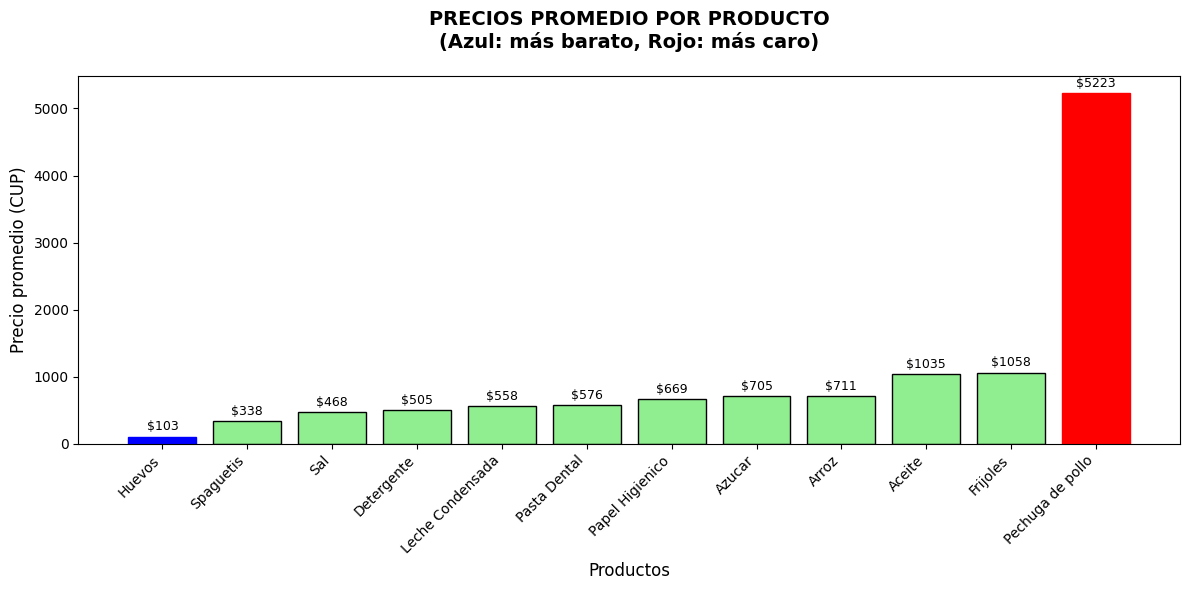

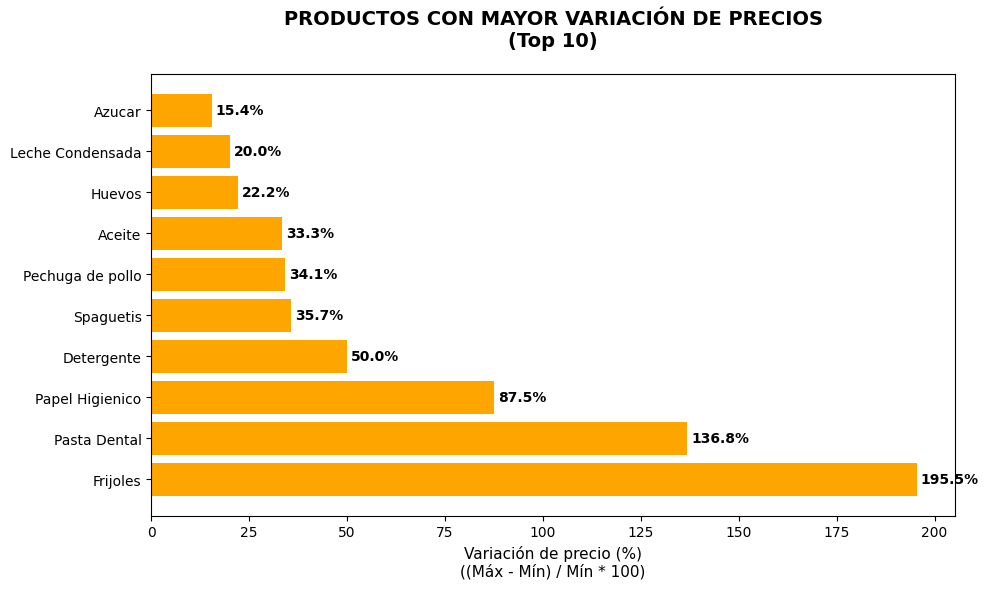

In [7]:
# notebooks/analisis2.ipynb

import sys
sys.path.append('../Biblioteca_Funciones')

# Importar funciones de precios
import A2 as pr
import A1 as an

datos = an.cargar_datos('../Data/procesados/productos_planos.json')
precios = pr.calcular_precios(datos)


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Extraer datos
productos = [p['producto'] for p in precios]
promedios = [p['promedio'] for p in precios]

# Crear gráfico de barras
bars = plt.bar(productos, promedios, color='lightgreen', edgecolor='black')

# Destacar el más caro y más barato
if mas_barato and mas_caro:
    idx_barato = productos.index(mas_barato['producto'])
    idx_caro = productos.index(mas_caro['producto'])

    bars[idx_barato].set_color('blue')
    bars[idx_caro].set_color('red')

# Personalizar
plt.xlabel('Productos', fontsize=12)
plt.ylabel('Precio promedio (CUP)', fontsize=12)
plt.title('PRECIOS PROMEDIO POR PRODUCTO\n(Azul: más barato, Rojo: más caro)',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')

# Agregar valores en las barras
for bar, promedio in zip(bars, promedios):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'${promedio:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

# Calcular variaciones
variaciones = pr.calcular_variacion_precios(precios)

# Tomar los 10 con mayor variación
top_variaciones = variaciones[:10]

productos_var = [v['producto'] for v in top_variaciones]
valores_var = [v['variacion'] for v in top_variaciones]

# Gráfico de barras horizontales
plt.barh(productos_var, valores_var, color='orange')

plt.xlabel('Variación de precio (%)\n((Máx - Mín) / Mín * 100)', fontsize=11)
plt.title('PRODUCTOS CON MAYOR VARIACIÓN DE PRECIOS\n(Top 10)',
          fontsize=14, fontweight='bold', pad=20)

# Agregar valores
for i, (prod, var) in enumerate(zip(productos_var, valores_var)):
    plt.text(var + 1, i, f'{var:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Calcular estadísticas generales
todos_precios = []
for registro in datos:
    todos_precios.append(registro['precio_cup'])

precio_promedio_general = sum(todos_precios) / len(todos_precios)

